In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

import torch

from xgboost import XGBClassifier
from pandas.api.types import CategoricalDtype

from sklearn.metrics import confusion_matrix

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
os.chdir("/content/drive/MyDrive/3. Grad School/리스크 관리 경진대회")

In [15]:
data = pd.read_pickle("DATA/Health_Insurance_final.pkl")

#### Fairness Metrics

In [53]:
def get_sens_features(var_name, sens_config, x_train, x_val, x_test):
    """특정 변수에 대해 민감변수 속성 생성"""

    if var_name == 'gender':
        train_sens = x_train[var_name]
        val_sens = x_val[var_name]
        test_sens = x_test[var_name]

    if var_name == 'age':
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        train_sens = pd.cut(x_train[var_name], bins = bins, labels = labels)
        val_sens = pd.cut(x_val[var_name], bins = bins, labels = labels)
        test_sens = pd.cut(x_test[var_name], bins = bins, labels = labels)

    if var_name.lower() in ['c_gi', 'c_ie_t']:
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        var_name = var_name.upper()
        train_sens = pd.cut(x_train[var_name], bins = bins, labels = labels)
        val_sens = pd.cut(x_val[var_name], bins = bins, labels = labels)
        test_sens = pd.cut(x_test[var_name], bins = bins, labels = labels)

    if var_name.lower() == 'gender':
        train_sens = x_train[var_name]
        val_sens = x_val[var_name]
        test_sens = x_test[var_name]

    if var_name.lower() == 'c_h':
        train_sens = x_train['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])
        val_sens = x_val['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])
        test_sens = x_test['C_H_num'].map(sens_config[var_name]['c_h_map_inv'])

    if var_name.lower() == 'age_gender':
        bins, labels = sens_config[var_name]['bins'], sens_config[var_name]['labels']
        age_train_bin = pd.cut(x_train['age'], bins = bins, labels = labels)
        age_val_bin = pd.cut(x_val['age'], bins = bins, labels = labels)
        age_test_bin = pd.cut(x_test['age'], bins = bins, labels = labels)
        train_sens = pd.DataFrame({'gen_age': x_train['gender'].astype(str) + "_" + age_train_bin.astype(str)})
        val_sens = pd.DataFrame({'gen_age': x_val['gender'].astype(str) + "_" + age_val_bin.astype(str)})
        test_sens = pd.DataFrame({'gen_age': x_test['gender'].astype(str) + "_" + age_test_bin.astype(str)})

    return train_sens, val_sens, test_sens

In [54]:
sens_config = {
    'age':{
        'bins' : [0, 19, 29, 39, 49, 59, 69, 100],
        'labels' : ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    },
    'age_gender':{
        'bins' :  [0, 25, 40, 60, 100],
        'labels' : ['청년', '장년', '중년', '고령']
    },
    'c_gi':{
        'bins' : [-2, 0, 25, 50, 75, 100],
        'labels' : ['Unknown', 'GI_1', 'GI_2', 'GI_3', 'GI_4']
    },
    'c_ie_t':{
        'bins' : [-2, 0, 25, 50, 75, 100],
        'labels' :['Unknown', 'C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4']
    },
    'c_h':{
        'c_h_map_inv' : {500: 'H1', 5500: 'H2', 17500: 'H3', 37500: 'H4', 75000: 'H5', 150000: 'H6', -1: 'Unknown'}
    }
}

In [55]:
def get_fpr_by_group(y_true, y_pred, group_col, groups):
    df = pd.DataFrame({'true': y_true, 'pred': y_pred, 'group': groups})
    results = []

    if group_col == 'age_gender':
        order = ['F_청년', 'M_청년', 'F_장년', 'M_장년', 'F_중년', 'M_중년', 'F_고령', 'M_고령']
    elif group_col == 'age':
        order = ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    else:
        order = np.sort(df['group'].unique())

    for name in order:
        group = df[df['group'] == name]
        if len(group) == 0:
            continue

        tn, fp, fn, tp = confusion_matrix(group['true'], group['pred']).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        results.append({"Group": name, "FPR": fpr, "FP_Count":fp, "TN_Count":tn})
    return pd.DataFrame(results)

def plot_fpr_by_group(fpr_results, group_col, y_max = None):
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x='Group', y='FPR', data=fpr_results, hue='Group', palette='Blues')

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=1, labels=[f'{v.get_height()*100:.2f}%' for v in container])

    if group_col in ['age', 'gender']:
        graph_label = group_col.capitalize()
    elif group_col == 'age_gender':
        graph_label = 'Age & Gender'
    else:
        graph_label = group_col.upper()

    # baseline 기준으로 y 최대 맞추기
    if y_max is not None:
        ax.set_ylim(0, y_max * 1.15)

    plt.title(f'False Positive Rate (FPR) by {graph_label}')
    plt.ylabel('FPR (Predict 1 when Actual 0)')
    plt.show()

def plot_fpr(y_true, y_pred, group_col, groups, y_max = None):
    fpr_results = get_fpr_by_group(y_true, y_pred, group_col, groups)
    plot_fpr_by_group(fpr_results, group_col, y_max = y_max)
    return fpr_results['FPR'].max()

In [56]:
def get_fairness_summary(y_true, y_pred, group_col, groups):
    df = pd.DataFrame({'true': y_true, 'pred': y_pred, 'group': groups})
    summary = []

    if group_col == 'age_gender':
        order = ['F_청년', 'M_청년', 'F_장년', 'M_장년', 'F_중년', 'M_중년', 'F_고령', 'M_고령']
    elif group_col == 'age':
        order = ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    else:
        order = np.sort(df['group'].unique())

    for name in order:
        temp = df[df['group'] == name]
        if len(temp) == 0:
            continue

        tn, fp, fn, tp = confusion_matrix(temp['true'], temp['pred']).ravel()

        # 1. Parity
        parity = (tp + fp) / len(temp)
        # 2. Equalized Odds
        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0

        summary.append({
            f'{group_col}'.capitalize(): name,
            'True': round(temp['true'].mean(), 4),
            'Pred': round(temp['pred'].mean(), 4),
            'Parity': round(parity, 4),
            'TPR (Recall)': round(tpr, 4),
            'FPR (False Positive)': round(fpr, 4),
            'Precision': round(precision, 4)
        })

    return pd.DataFrame(summary)

import seaborn as sns
import matplotlib.pyplot as plt

def plot_fairness_heatmap(fairness_summary, group_col):
    styled_df = fairness_summary.style.format({
        'True Rate': '{:.2%}',
        'Pred Rate': '{:.2%}',
        'Parity': '{:.2%}',
        'TPR (Recall)': '{:.2%}',
        'FPR (False Positive)': '{:.2%}',
        'Precision': '{:.2%}'
    })

    cols_to_style = ['True', 'Pred', 'Parity', 'TPR (Recall)', 'FPR (False Positive)', 'Precision']
    for col in cols_to_style:
        styled_df = styled_df.background_gradient(cmap = 'Blues', subset = [col], axis = 0)

    return styled_df

def plot_fairness(y_true, y_pred, group_col, groups):
    fairness_summary = get_fairness_summary(y_true, y_pred, group_col, groups)
    styled_df = plot_fairness_heatmap(fairness_summary, group_col)
    display(styled_df)

#### 최종 실행 함수

In [63]:
def fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred):
    x_train_sensitive, x_val_sensitive, x_test_sensitive = get_sens_features(var_name, sens_config, x_train, x_val, x_test)
    fpr_results_org = get_fpr_by_group(y_test, y_pred, var_name, x_test_sensitive.squeeze())
    baseline_y_max = fpr_results_org['FPR'].max()
    plot_fpr(y_test, y_pred, var_name, x_test_sensitive.squeeze(), baseline_y_max)
    plot_fairness(y_test, y_pred, var_name, x_test_sensitive.squeeze())

### 직접 차별 (전체 변수)

#### 최종 설정

In [58]:
target = 'is_churn'

x_cols = [
    # 기본
    'premium', 'seniority_policy', 'type_policy_dg', 'type_product', 'new_business',
    'log_cost_claims_year', 'distribution_channel',
    # 나이 관련
    'age',
    # 성별 관련
    'gender',
    # 지역 관련
    'IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T',
]

der_cols = [
    'missing_geo_cxt',       # 지역 결측 신호
    'high_loss',                  # 보험사 손해율
    'relative_poverty',        # 지역 내 상대적 빈곤
    'kr_premium_shock',   # 가격 인상 압박(비율 단위)
    'kr_economic_stress',  # 소득 대비 체감 부담
    # 'kr_retention_years',    # 장기 유지 혜택
    'kr_early_laps',             #신계약 위험 구간
    # 'kr_direct_channel',     # 가입 채널 영향
    'kr_medical_desert'     # 인프라 취약성
]

print(f"사용 변수 개수(기본) : {len(x_cols)}")
print(f"사용 변수 개수(파생) : {len(der_cols)}")
x_cols += der_cols
print(f"최종 변수 개수 : {len(x_cols)}개")

device = "cuda" if torch.cuda.is_available() else "cpu"

사용 변수 개수(기본) : 15
사용 변수 개수(파생) : 7
최종 변수 개수 : 22개


In [59]:
### Encoding
cat_cols = ['type_policy_dg', 'type_product', 'new_business', 'distribution_channel', 'gender', 'C_C', 'kr_early_laps']

In [60]:
import joblib
# XGBoost
model_data = joblib.load("Model/xgb_package2.pkl")
model = model_data['model']

y_pred = joblib.load("Model/xgb_pred2.pkl")

In [61]:
### train/test split
for col in cat_cols:
    data[col] = data[col].astype(str).astype('category')

train = data[data['period'].isin([2017, 2018])]
val = data[data['period'] == 2018]
test = data[data['period'] == 2019]

x_train = train[x_cols]
y_train = train[target]
x_val = val[x_cols]
y_val = val[target]
x_test = test[x_cols]
y_test = test[target]

device = "cuda" if torch.cuda.is_available() else "cpu"

#### 성별

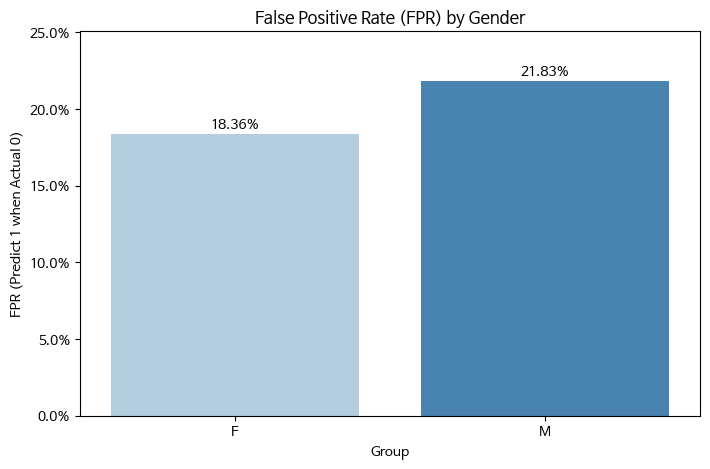

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.239600,23.96%,53.28%,18.36%,35.65%
1,M,0.162200,0.268400,26.84%,52.68%,21.83%,31.84%


In [64]:
var_name = "gender"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

#### 나이

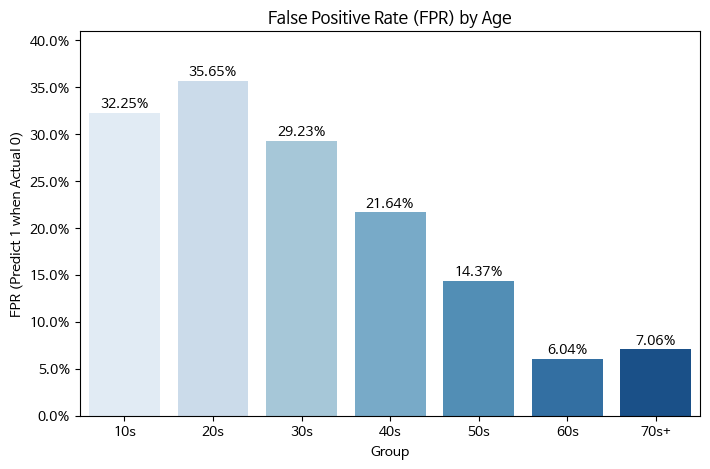

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.384400,38.44%,60.34%,32.25%,34.56%
1,20s,0.211600,0.417100,41.71%,64.32%,35.65%,32.62%
2,30s,0.206600,0.352000,35.20%,58.12%,29.23%,34.11%
3,40s,0.175900,0.267300,26.73%,50.61%,21.64%,33.29%
4,50s,0.133700,0.184100,18.41%,44.62%,14.37%,32.41%
5,60s,0.084700,0.083700,8.37%,33.57%,6.04%,33.96%
6,70s+,0.094200,0.099500,9.95%,37.77%,7.06%,35.76%


In [65]:
var_name = "age"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

#### 나이 & 성별

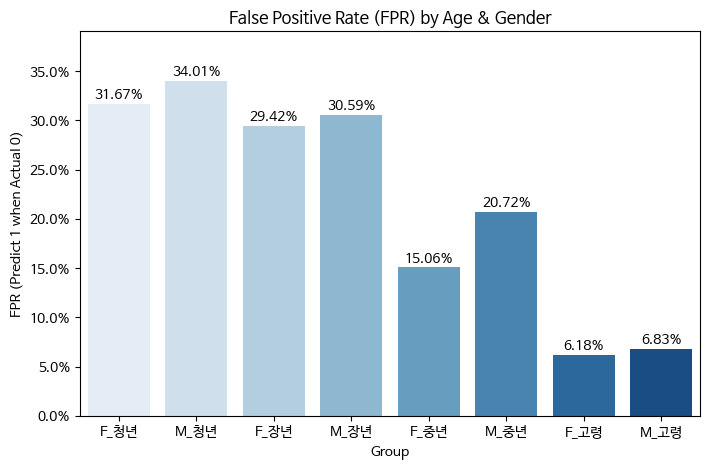

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.383100,38.31%,61.46%,31.67%,35.78%
1,M_청년,0.214100,0.396100,39.61%,60.15%,34.01%,32.51%
2,F_장년,0.213200,0.359100,35.91%,59.87%,29.42%,35.54%
3,M_장년,0.196700,0.358600,35.86%,57.39%,30.59%,31.48%
4,F_중년,0.152600,0.201400,20.14%,48.32%,15.06%,36.62%
5,M_중년,0.153400,0.249000,24.90%,47.99%,20.72%,29.56%
6,F_고령,0.083400,0.085000,8.50%,34.00%,6.18%,33.37%
7,M_고령,0.095700,0.097700,9.77%,37.56%,6.83%,36.79%


In [66]:
var_name = "age_gender"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

#### 지역

- `C_H`

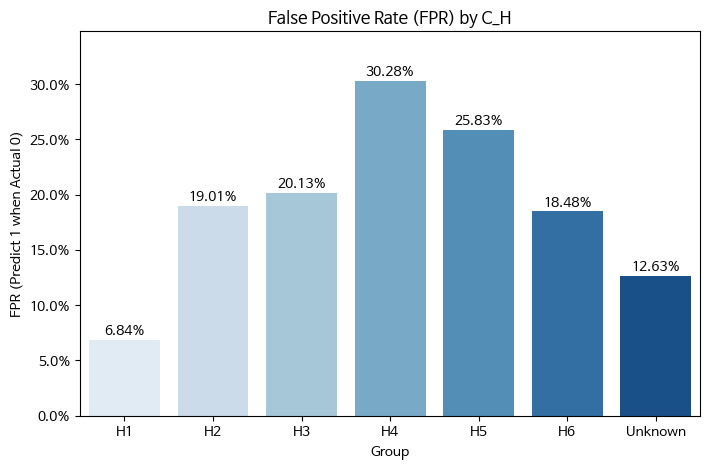

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.094900,9.49%,26.79%,6.84%,37.50%
1,H2,0.182200,0.251800,25.18%,52.87%,19.01%,38.26%
2,H3,0.194600,0.262200,26.22%,51.44%,20.13%,38.17%
3,H4,0.191200,0.360700,36.07%,60.57%,30.28%,32.11%
4,H5,0.200300,0.325300,32.53%,59.32%,25.83%,36.52%
5,H6,0.142700,0.231600,23.16%,51.25%,18.48%,31.59%
6,Unknown,0.112600,0.170100,17.01%,51.54%,12.63%,34.10%


In [68]:
### C_H (인구 수)
var_name = "c_h"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

- `C_GI`

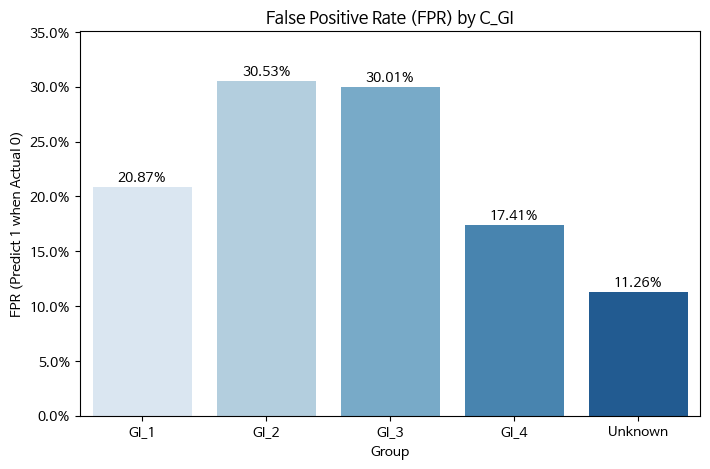

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.281900,28.19%,55.47%,20.87%,41.60%
1,GI_2,0.232200,0.377800,37.78%,61.75%,30.53%,37.95%
2,GI_3,0.209700,0.372600,37.26%,64.58%,30.01%,36.35%
3,GI_4,0.143700,0.218100,21.81%,48.07%,17.41%,31.67%
4,Unknown,0.115600,0.153300,15.33%,46.46%,11.26%,35.04%


In [69]:
### C_GI (소득 수준)
var_name = "c_gi"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

- `C_IE_T`

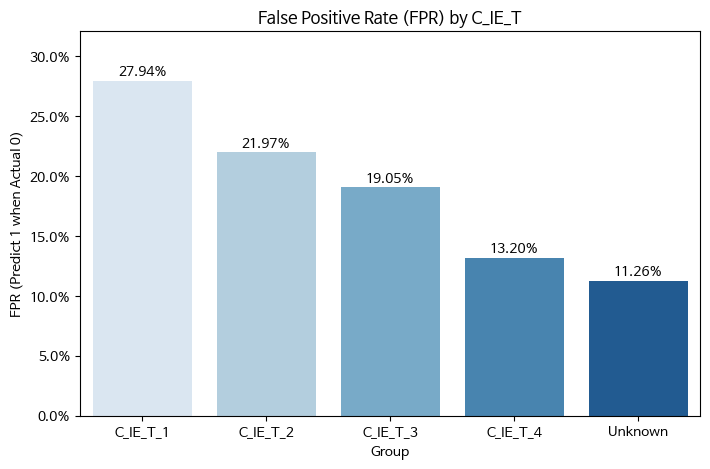

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.345900,34.59%,59.74%,27.94%,36.14%
1,C_IE_T_2,0.174000,0.278600,27.86%,55.77%,21.97%,34.84%
2,C_IE_T_3,0.144500,0.235900,23.59%,50.44%,19.05%,30.91%
3,C_IE_T_4,0.124900,0.167900,16.79%,41.96%,13.20%,31.20%
4,Unknown,0.115600,0.153300,15.33%,46.46%,11.26%,35.04%


In [70]:
### C_IE_T (교육 수준)
var_name = "c_ie_t"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

#### SHAP

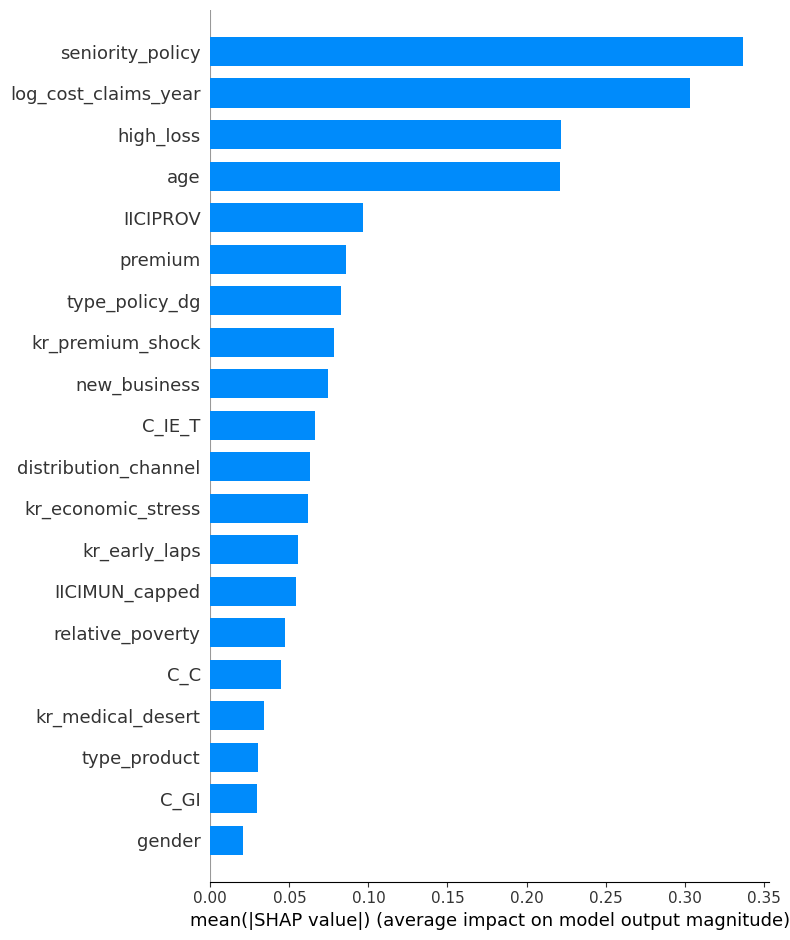

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)

shap.summary_plot(shap_values, x_test, plot_type = "bar")

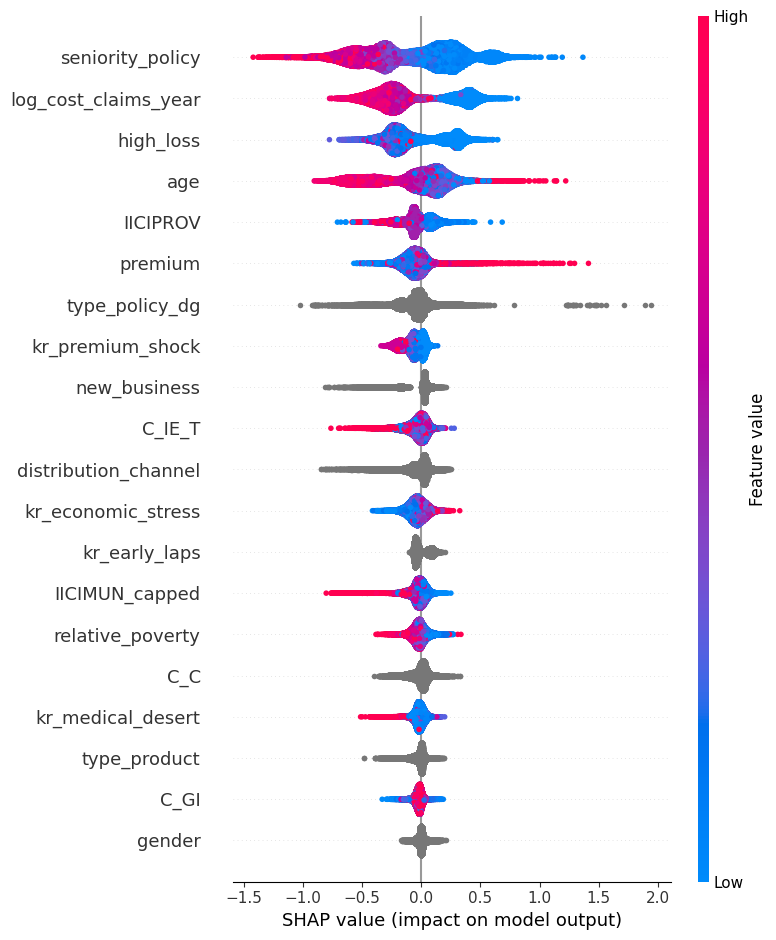

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)

shap.summary_plot(shap_values, x_test)

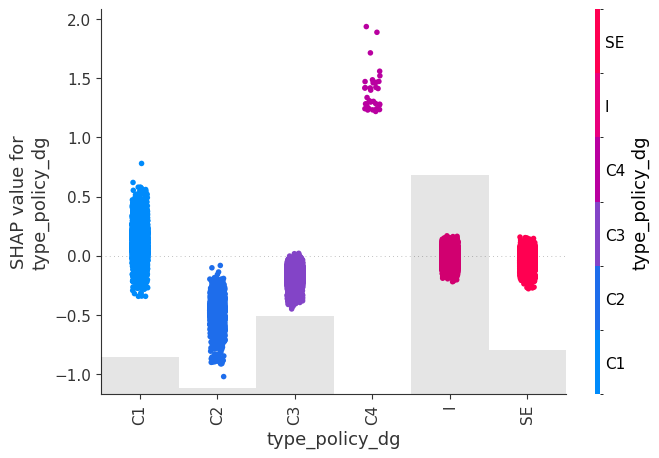

In [ ]:
shap.plots.scatter(explainer(x_test)[:, "type_policy_dg"], color=explainer(x_test)[:, "type_policy_dg"])

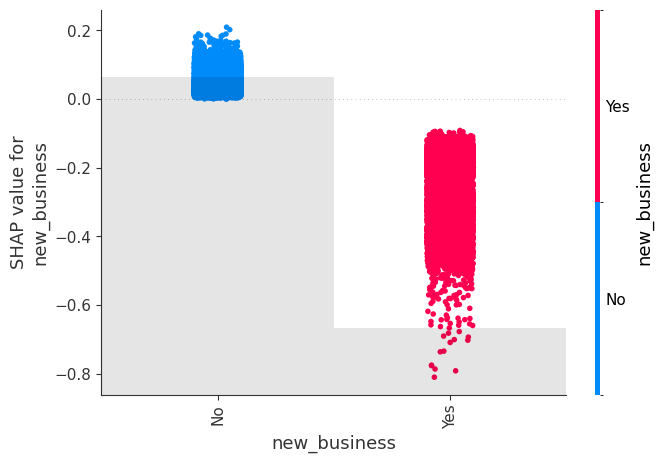

In [ ]:
shap.plots.scatter(explainer(x_test)[:, "new_business"], color=explainer(x_test)[:, "new_business"])

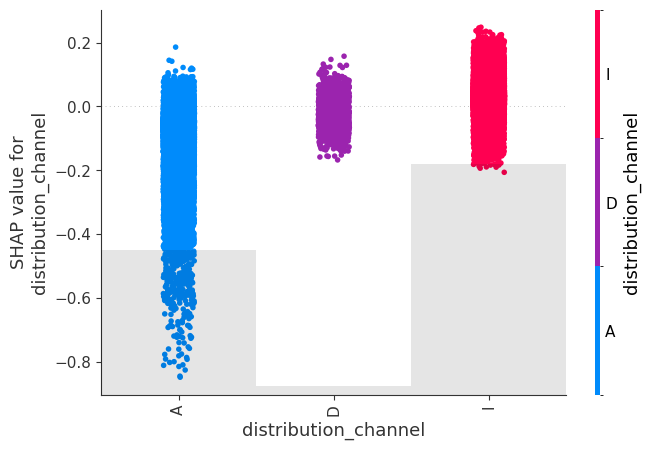

In [ ]:
shap.plots.scatter(explainer(x_test)[:, "distribution_channel"], color=explainer(x_test)[:, "distribution_channel"])

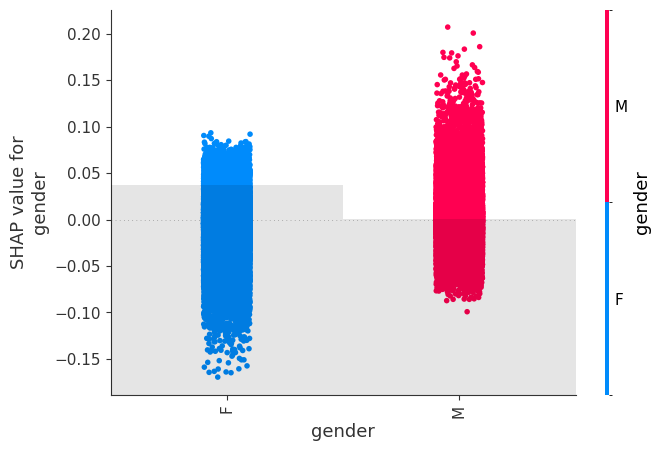

In [ ]:
shap.plots.scatter(explainer(x_test)[:, "gender"], color=explainer(x_test)[:, "gender"])

### 간접 차별 (변수 제거)

#### 모델 학습 함수

In [71]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, roc_auc_score, average_precision_score\

import shap
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

spw = (y_train == 0).sum() / (y_train == 1).sum()

def fit_xgb(use_cols):
    xgb_model = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 10,
    scale_pos_weight = spw,  # 데이터 불균형 처리
    random_state = 1742,
    eval_metric = 'logloss',
    tree_method = 'hist',
    enable_categorical = True,
    device = device
)

    xgb_model.fit(x_train[use_cols], y_train)

    y_pred = xgb_model.predict(x_test[use_cols])
    y_prob = xgb_model.predict_proba(x_test[use_cols])[:, 1]

    print(classification_report(y_test, y_pred))
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    print(f"Final Results (Lapsed Class):")
    print(f"- F1-Score: {f1:.4f}")
    print(f"- PR-AUC: {pr_auc:.4f}")
    print(f"- Precision (정밀도): {precision:.4f}")
    print(f"- Recall (재현율): {recall:.4f}")

    explainer = shap.TreeExplainer(xgb_model, feature_perturbation='interventional')
    shap_values = explainer.shap_values(x_test[use_cols], check_additivity=False)

    shap.summary_plot(shap_values, x_test[use_cols], plot_type = "bar")
    print("="*30)
    shap.summary_plot(shap_values, x_test[use_cols])

    return xgb_model, y_pred, y_prob

#### 성별 제어

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [13:56:54] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


              precision    recall  f1-score   support

           0       0.89      0.86      0.87     63472
           1       0.37      0.43      0.40     12195

    accuracy                           0.79     75667
   macro avg       0.63      0.64      0.63     75667
weighted avg       0.80      0.79      0.80     75667

Final Results (Lapsed Class):
- F1-Score: 0.3953
- PR-AUC: 0.3875
- Precision (정밀도): 0.3690
- Recall (재현율): 0.4255


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:265: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


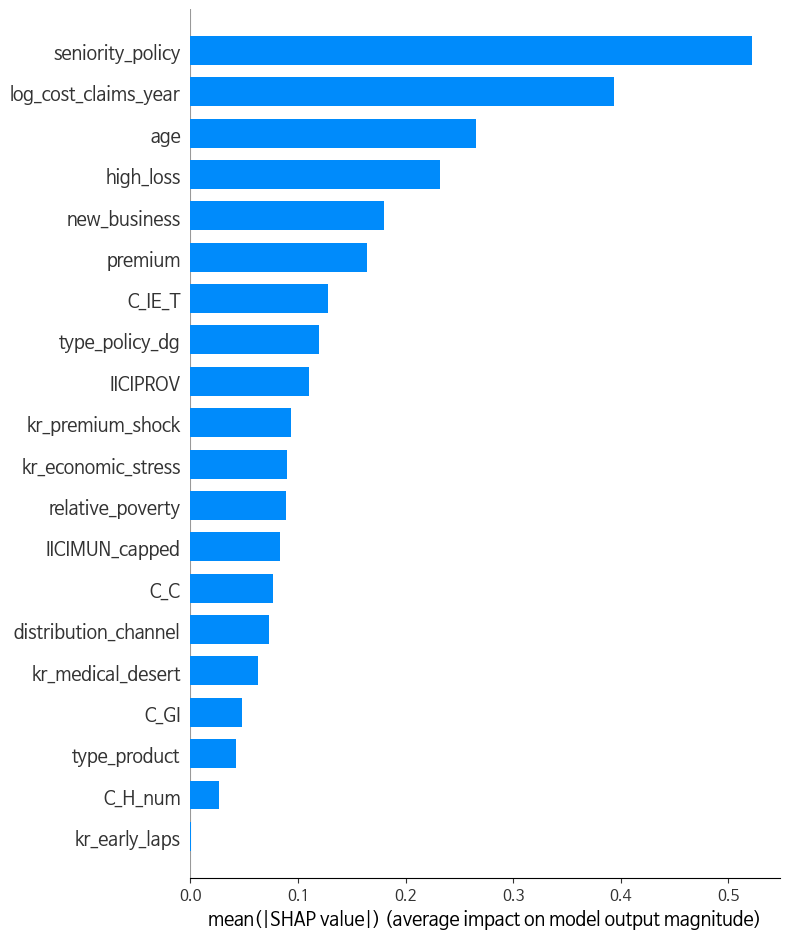

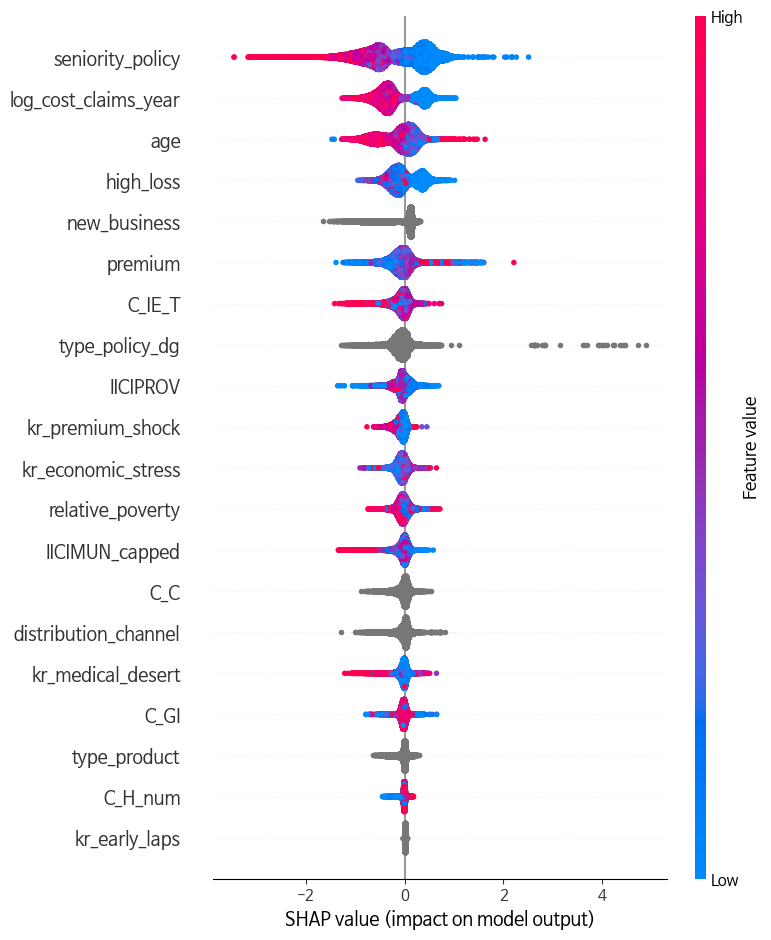

In [72]:
ex_cols = ['gender']
gender_cols = list(set(x_cols) - set(ex_cols))

model, y_pred, y_prob  = fit_xgb(gender_cols)

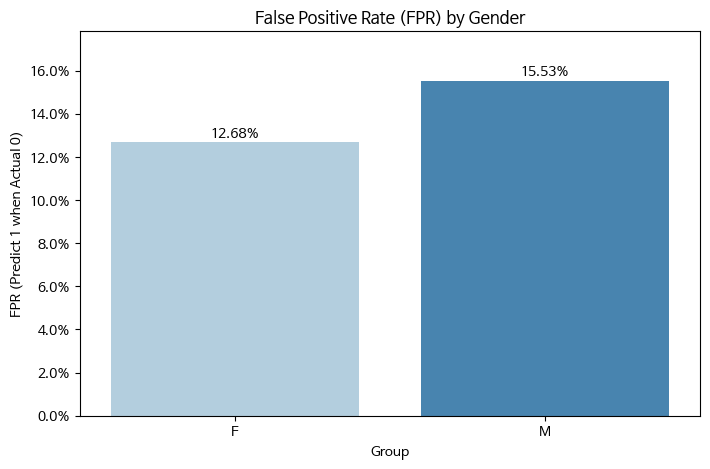

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.174400,17.44%,42.38%,12.68%,38.95%
1,M,0.162200,0.199400,19.94%,42.75%,15.53%,34.77%


In [73]:
var_name = "gender"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

#### 나이 제어

              precision    recall  f1-score   support

           0       0.89      0.83      0.86     63472
           1       0.33      0.44      0.38     12195

    accuracy                           0.77     75667
   macro avg       0.61      0.64      0.62     75667
weighted avg       0.80      0.77      0.78     75667

Final Results (Lapsed Class):
- F1-Score: 0.3795
- PR-AUC: 0.3541
- Precision (정밀도): 0.3320
- Recall (재현율): 0.4428


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:265: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


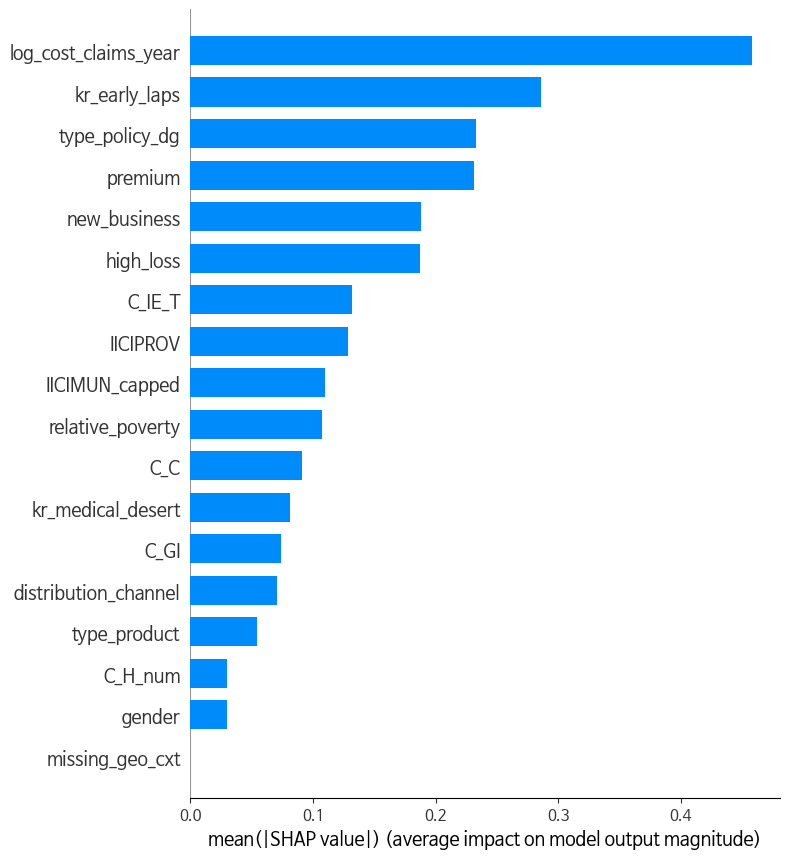

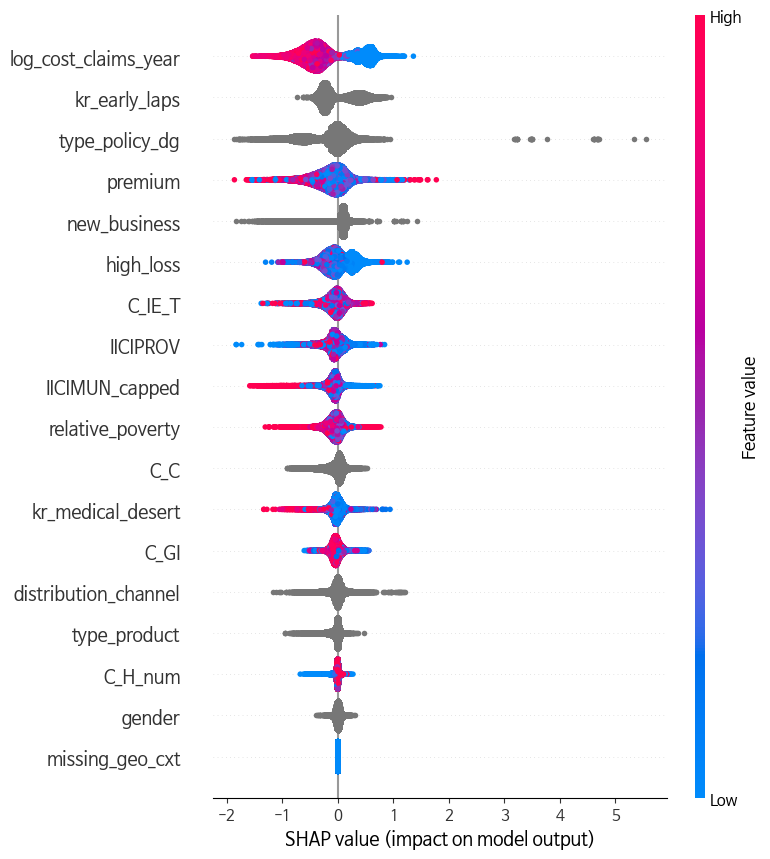

In [74]:
ex_cols = ['age', 'seniority_policy', 'kr_premium_shock', 'kr_economic_stress']
age_cols = list(set(x_cols) - set(ex_cols))

model, y_pred, y_prob  = fit_xgb(age_cols)

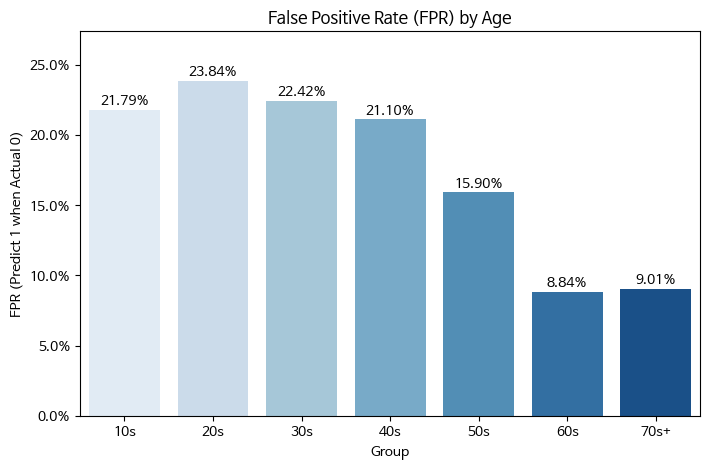

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.269600,26.96%,45.28%,21.79%,36.98%
1,20s,0.211600,0.290800,29.08%,48.61%,23.84%,35.37%
2,30s,0.206600,0.273700,27.37%,46.39%,22.42%,35.01%
3,40s,0.175900,0.255800,25.58%,46.56%,21.10%,32.02%
4,50s,0.133700,0.194800,19.48%,42.68%,15.90%,29.30%
5,60s,0.084700,0.111700,11.17%,36.37%,8.84%,27.57%
6,70s+,0.094200,0.114600,11.46%,35.05%,9.01%,28.82%


In [75]:
var_name = "age"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

#### 나이, 성별 제어

              precision    recall  f1-score   support

           0       0.89      0.84      0.86     63472
           1       0.34      0.44      0.38     12195

    accuracy                           0.77     75667
   macro avg       0.61      0.64      0.62     75667
weighted avg       0.80      0.77      0.78     75667

Final Results (Lapsed Class):
- F1-Score: 0.3797
- PR-AUC: 0.3533
- Precision (정밀도): 0.3368
- Recall (재현율): 0.4351


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:265: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


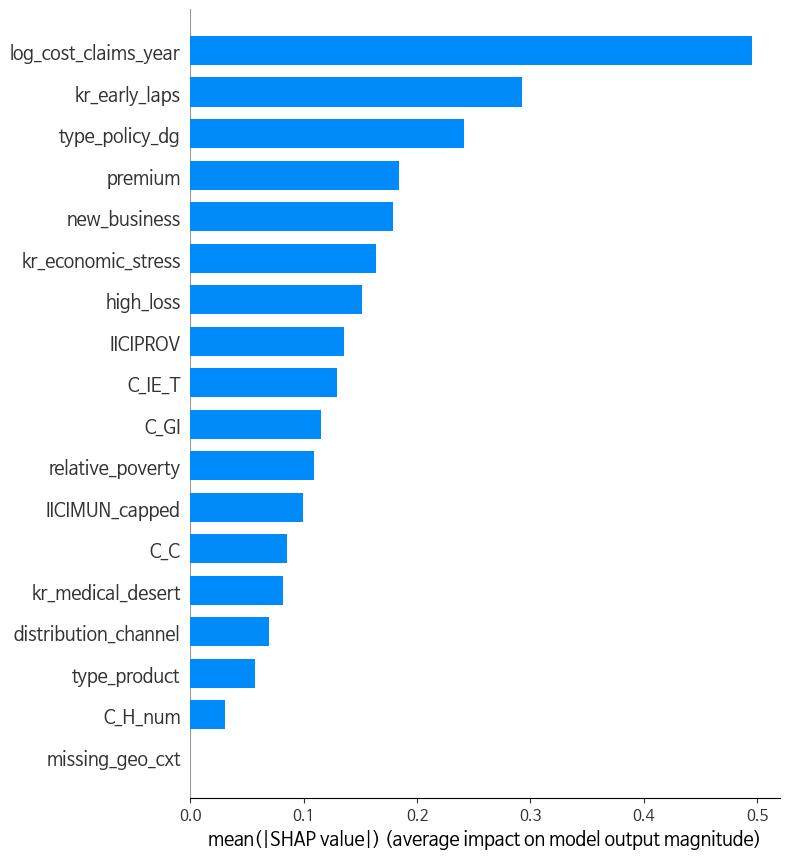

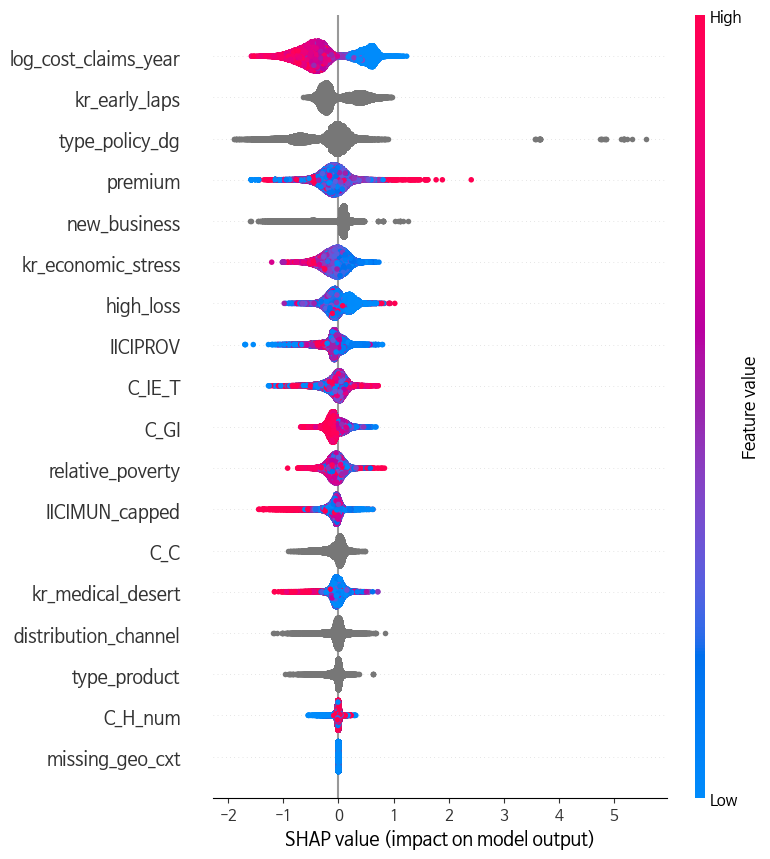

In [76]:
ex_cols1 = ['age', 'seniority_policy', 'kr_premium_shock']
ex_cols2 = ['gender']
ex_cols = ex_cols1 + ex_cols2
age_gender_cols = [col for col in x_cols if col not in ex_cols]

model, y_pred, y_prob  = fit_xgb(age_gender_cols)

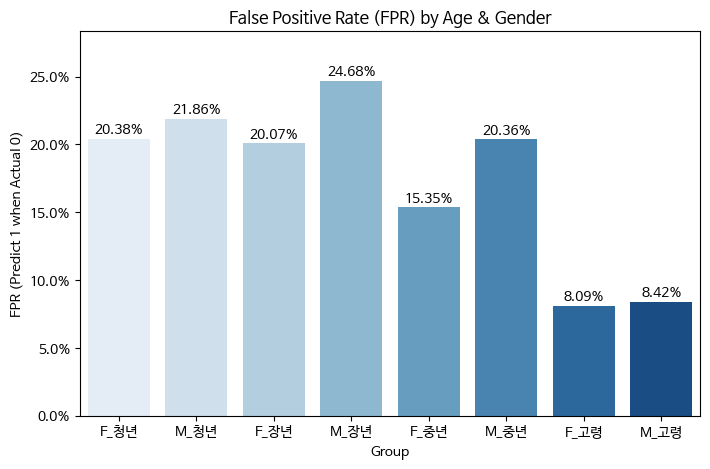

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.259400,25.94%,45.28%,20.38%,38.94%
1,M_청년,0.214100,0.267700,26.77%,44.77%,21.86%,35.81%
2,F_장년,0.213200,0.254000,25.40%,45.04%,20.07%,37.81%
3,M_장년,0.196700,0.293900,29.39%,48.61%,24.68%,32.54%
4,F_중년,0.152600,0.196000,19.60%,43.18%,15.35%,33.62%
5,M_중년,0.153400,0.241300,24.13%,44.89%,20.36%,28.54%
6,F_고령,0.083400,0.102200,10.22%,33.70%,8.09%,27.48%
7,M_고령,0.095700,0.109300,10.93%,34.65%,8.42%,30.35%


In [77]:
var_name = "age_gender"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

#### 지역 제어

              precision    recall  f1-score   support

           0       0.89      0.80      0.84     63472
           1       0.32      0.50      0.39     12195

    accuracy                           0.75     75667
   macro avg       0.61      0.65      0.62     75667
weighted avg       0.80      0.75      0.77     75667

Final Results (Lapsed Class):
- F1-Score: 0.3899
- PR-AUC: 0.3635
- Precision (정밀도): 0.3214
- Recall (재현율): 0.4954


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:265: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


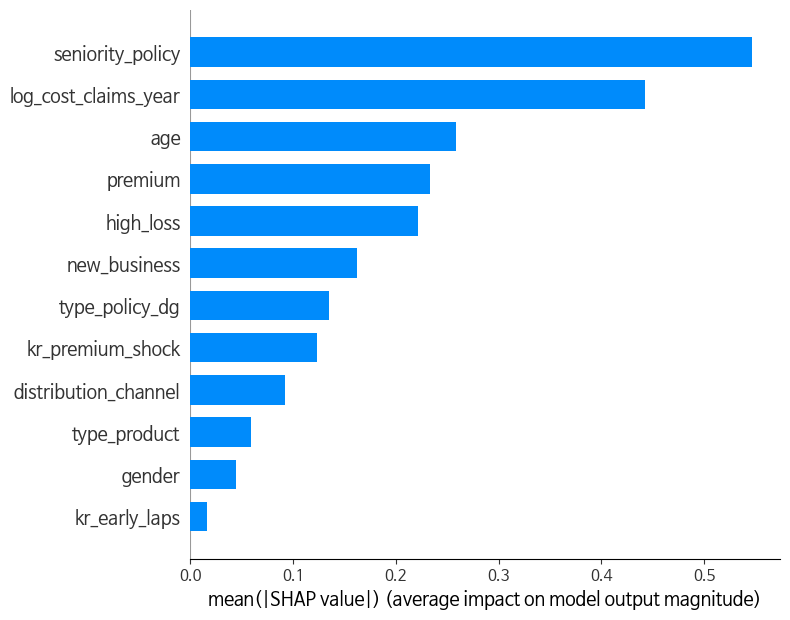

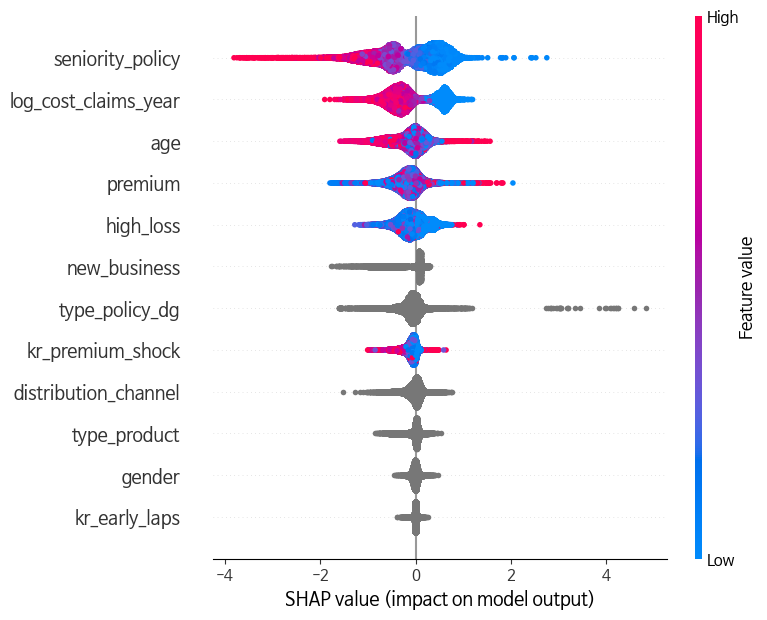

In [78]:
ex_cols = ['IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T', 'missing_geo_cxt', 'relative_poverty', 'kr_economic_stress', 'kr_medical_desert']
geo_cols = list(set(x_cols) - set(ex_cols))

model, y_pred, y_prob  = fit_xgb(geo_cols)

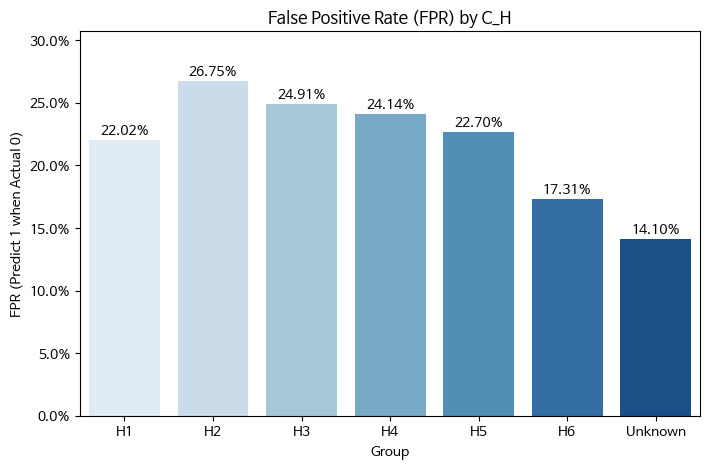

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.252700,25.27%,46.43%,22.02%,24.41%
1,H2,0.182200,0.322000,32.20%,56.66%,26.75%,32.06%
2,H3,0.194600,0.307200,30.72%,54.81%,24.91%,34.71%
3,H4,0.191200,0.290800,29.08%,49.96%,24.14%,32.85%
4,H5,0.200300,0.284800,28.48%,51.55%,22.70%,36.26%
5,H6,0.142700,0.214400,21.44%,46.25%,17.31%,30.79%
6,Unknown,0.112600,0.169700,16.97%,39.62%,14.10%,26.28%


In [79]:
### C_H (인구 수)
var_name = "c_h"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

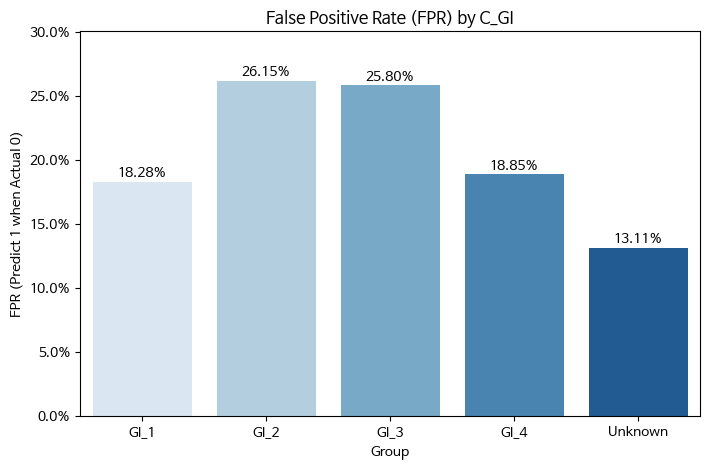

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.252800,25.28%,51.40%,18.28%,42.98%
1,GI_2,0.232200,0.324300,32.43%,53.22%,26.15%,38.10%
2,GI_3,0.209700,0.324400,32.44%,57.47%,25.80%,37.16%
3,GI_4,0.143700,0.228700,22.87%,46.83%,18.85%,29.43%
4,Unknown,0.115600,0.161800,16.18%,39.66%,13.11%,28.34%


In [80]:
### C_GI (소득 수준)
var_name = "c_gi"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

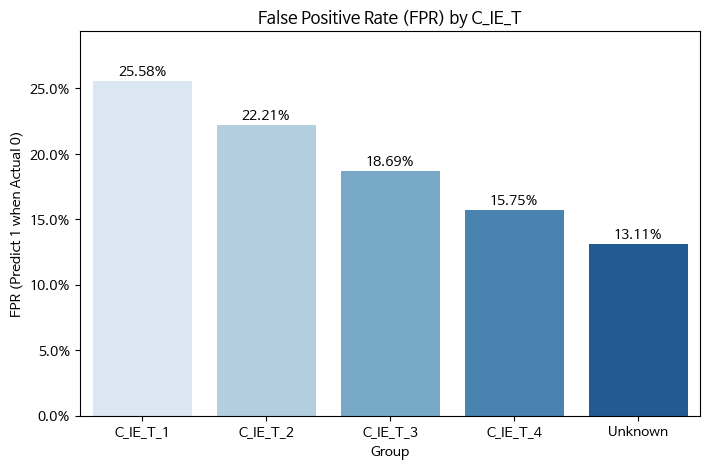

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.315300,31.53%,54.06%,25.58%,35.87%
1,C_IE_T_2,0.174000,0.274300,27.43%,52.19%,22.21%,33.12%
2,C_IE_T_3,0.144500,0.227700,22.77%,46.93%,18.69%,29.79%
3,C_IE_T_4,0.124900,0.191400,19.14%,42.88%,15.75%,27.97%
4,Unknown,0.115600,0.161800,16.18%,39.66%,13.11%,28.34%


In [81]:
### C_IE_T (교육 수준)
var_name = "c_ie_t"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

#### 민감변수 모두 제어

              precision    recall  f1-score   support

           0       0.90      0.72      0.80     63472
           1       0.28      0.56      0.38     12195

    accuracy                           0.70     75667
   macro avg       0.59      0.64      0.59     75667
weighted avg       0.80      0.70      0.73     75667

Final Results (Lapsed Class):
- F1-Score: 0.3764
- PR-AUC: 0.3324
- Precision (정밀도): 0.2822
- Recall (재현율): 0.5647


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:265: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


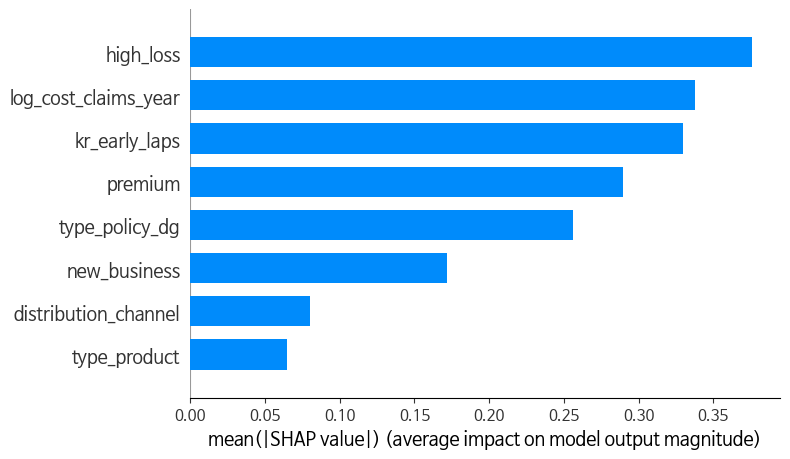

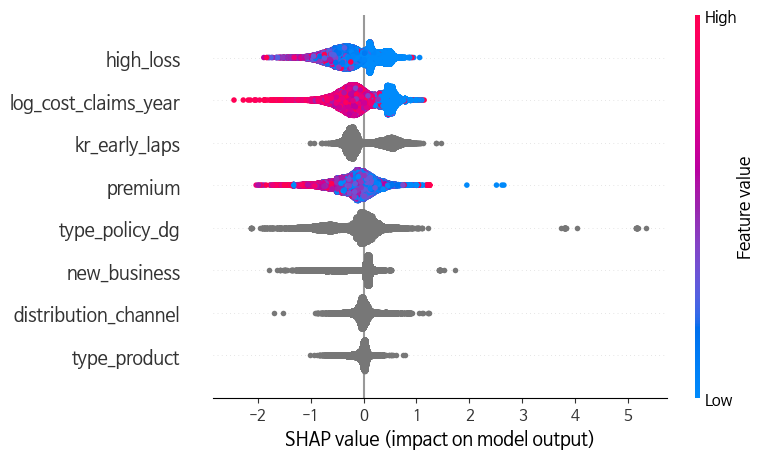

In [82]:
ex_cols1 = ['gender']
ex_cols2 = ['age', 'seniority_policy', 'kr_premium_shock', 'kr_economic_stress']
ex_cols3 = ['IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T', 'missing_geo_cxt', 'relative_poverty', 'kr_economic_stress', 'kr_medical_desert']

ex_cols = ex_cols1 + ex_cols2 + ex_cols3
all_sens_cols = [col for col in x_cols if col not in ex_cols]

model, y_pred, y_prob  = fit_xgb(all_sens_cols)

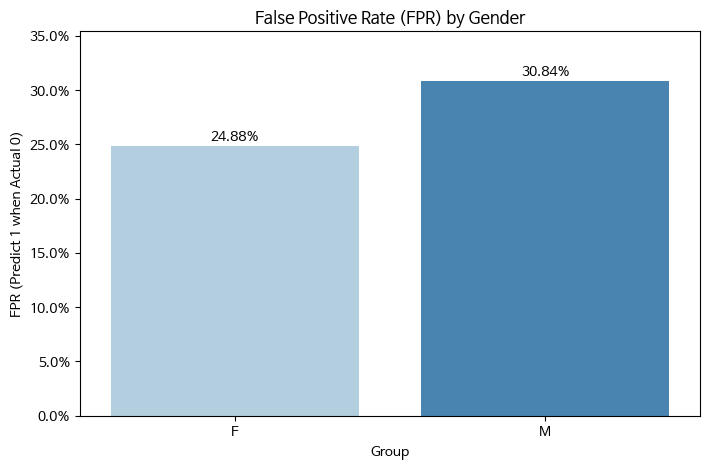

,Gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F,0.160300,0.296900,29.69%,54.87%,24.88%,29.63%
1,M,0.162200,0.353000,35.30%,58.36%,30.84%,26.82%


In [83]:
var_name = "gender"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

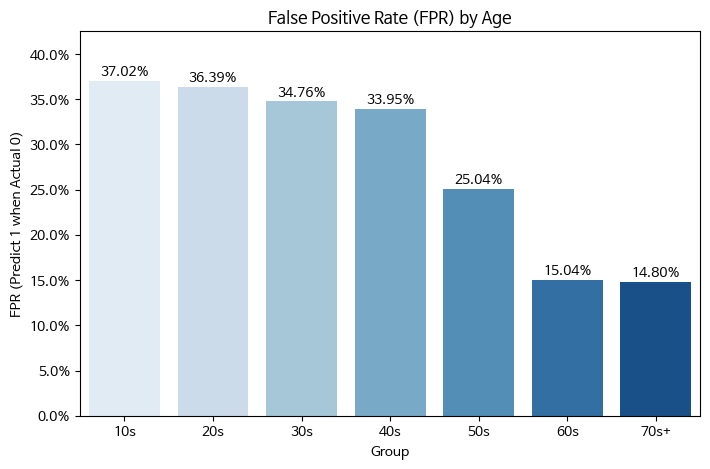

,Age,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,10s,0.220200,0.417500,41.75%,58.49%,37.02%,30.85%
1,20s,0.211600,0.419400,41.94%,62.62%,36.39%,31.59%
2,30s,0.206600,0.394000,39.40%,57.25%,34.76%,30.01%
3,40s,0.175900,0.380100,38.01%,57.06%,33.95%,26.40%
4,50s,0.133700,0.290600,29.06%,55.08%,25.04%,25.35%
5,60s,0.084700,0.178000,17.80%,47.60%,15.04%,22.65%
6,70s+,0.094200,0.180300,18.03%,49.09%,14.80%,25.66%


In [84]:
var_name = "age"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

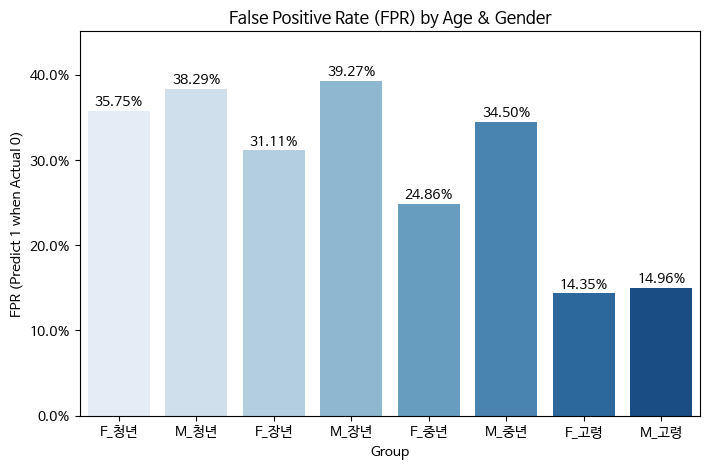

,Age_gender,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,F_청년,0.223100,0.408100,40.81%,58.44%,35.75%,31.94%
1,M_청년,0.214100,0.428900,42.89%,59.75%,38.29%,29.83%
2,F_장년,0.213200,0.364700,36.47%,56.24%,31.11%,32.88%
3,M_장년,0.196700,0.436800,43.68%,61.72%,39.27%,27.80%
4,F_중년,0.152600,0.292200,29.22%,53.46%,24.86%,27.92%
5,M_중년,0.153400,0.383000,38.30%,59.26%,34.50%,23.73%
6,F_고령,0.083400,0.171600,17.16%,48.09%,14.35%,23.36%
7,M_고령,0.095700,0.181500,18.15%,48.26%,14.96%,25.44%


In [85]:
var_name = "age_gender"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

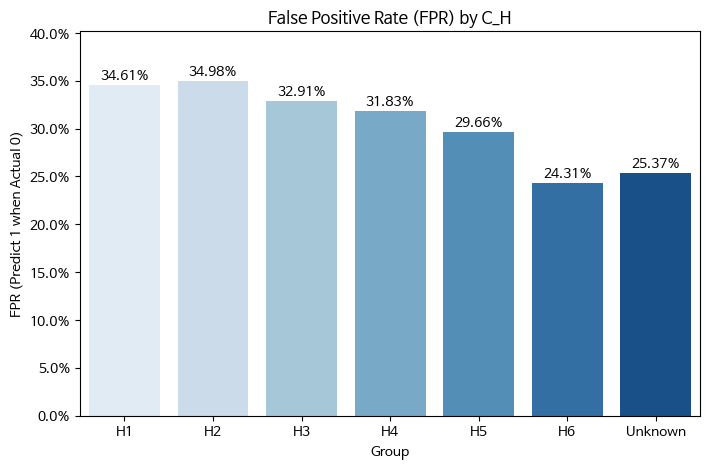

,C_h,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,H1,0.132900,0.372500,37.25%,54.46%,34.61%,19.43%
1,H2,0.182200,0.399500,39.95%,62.25%,34.98%,28.39%
2,H3,0.194600,0.377100,37.71%,57.59%,32.91%,29.71%
3,H4,0.191200,0.363800,36.38%,55.60%,31.83%,29.23%
4,H5,0.200300,0.354100,35.41%,58.39%,29.66%,33.03%
5,H6,0.142700,0.286000,28.60%,54.39%,24.31%,27.14%
6,Unknown,0.112600,0.294400,29.44%,61.54%,25.37%,23.53%


In [88]:
var_name = "c_h"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

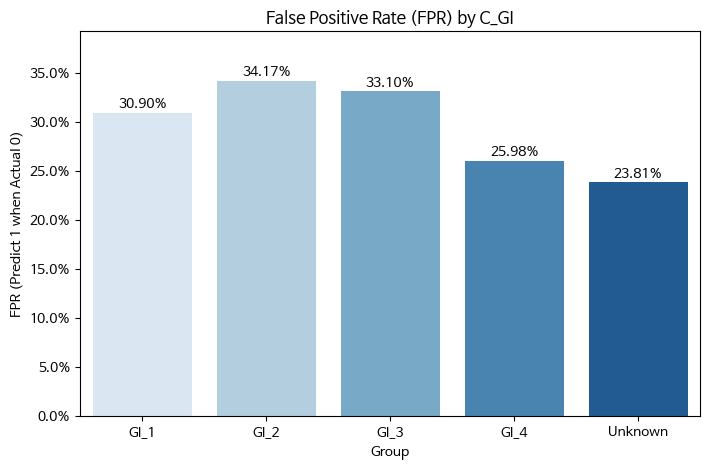

,C_gi,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,GI_1,0.211400,0.367400,36.74%,58.52%,30.90%,33.67%
1,GI_2,0.232200,0.399800,39.98%,59.17%,34.17%,34.37%
2,GI_3,0.209700,0.389400,38.94%,60.94%,33.10%,32.82%
3,GI_4,0.143700,0.300600,30.06%,54.38%,25.98%,26.00%
4,Unknown,0.115600,0.279700,27.97%,59.77%,23.81%,24.71%


In [87]:
var_name = "c_gi"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)

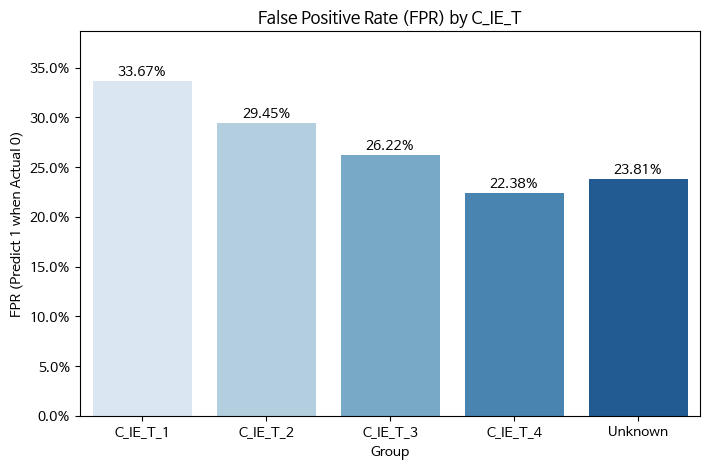

,C_ie_t,True,Pred,Parity,TPR (Recall),FPR (False Positive),Precision
0,C_IE_T_1,0.209300,0.390400,39.04%,59.31%,33.67%,31.79%
1,C_IE_T_2,0.174000,0.343200,34.32%,57.45%,29.45%,29.13%
2,C_IE_T_3,0.144500,0.304400,30.44%,55.43%,26.22%,26.32%
3,C_IE_T_4,0.124900,0.259600,25.96%,51.10%,22.38%,24.57%
4,Unknown,0.115600,0.279700,27.97%,59.77%,23.81%,24.71%


In [86]:
var_name = "c_ie_t"
fairness_check(var_name, sens_config, x_train, x_val, x_test, y_test, y_pred)